<a href="https://colab.research.google.com/github/Capechusami/E-Commerce-Online-Retail-Analysis/blob/main/Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#   CSEC Data Science Bootcamp Final Project : Advanced E-Commerce Online Retail Dataset Analysis

---

## 1. Business Context

In today’s highly competitive e-commerce landscape, companies generate massive amounts of transactional data daily. However, the true challenge lies not in collecting data, but in extracting meaningful insights that can drive strategic decision-making.

Organizations often rely on surface-level metrics such as average sales or total revenue. While useful, these metrics fail to capture deeper behavioral patterns such as:

- Which customers truly drive revenue?
- How purchasing behavior changes over time
- Whether revenue is evenly distributed or concentrated
- How geographic regions differ in performance
- Whether certain customer segments are more valuable than others

Without answering these questions, businesses risk making inefficient decisions, misallocating resources, and missing growth opportunities.

---

## 2. Problem Statement

The core problem addressed in this project is:

> How can we transform raw transactional retail data into actionable insights that improve customer targeting, revenue optimization, and strategic planning?

This requires going beyond descriptive statistics and applying **advanced analytical techniques**.

---

## 3. Objectives

The primary objectives of this analysis are:

### 3.1 Customer Understanding
- Identify high-value (VIP) customers
- Analyze customer spending behavior
- Detect revenue concentration patterns

### 3.2 Revenue Analysis
- Understand distribution of revenue across customers
- Identify key revenue drivers
- Evaluate inequality in customer contributions

### 3.3 Temporal Analysis
- Detect seasonal trends
- Identify peak purchasing periods
- Understand how revenue evolves over time

### 3.4 Geographic Insights
- Compare performance across countries
- Identify high-performing regions
- Detect regional demand variations

---

## 4. Analytical Approach

This project follows a structured data science workflow:

1. Data Understanding → Inspect structure and quality  
2. Data Cleaning → Ensure accuracy and reliability  
3. Feature Engineering → Create meaningful variables  
4. Advanced Analysis → Apply multi-dimensional techniques  
5. Visualization → Communicate insights clearly  
6. Insight Generation → Translate findings into business actions  

---

## 5. Advanced Techniques Applied

To ensure analytical depth, the following techniques are used:

- Cross-tabulation (multi-variable interaction)
- Percentile analysis (distribution understanding)
- Outlier detection (VIP identification)
- Cohort analysis (customer lifecycle)
- Ratio metrics (efficiency measurement)
- Time-series analysis (trend detection)
- Missing data analysis (hidden signals)

---

## 6. Expected Outcome

By the end of this analysis, we aim to:

- Reveal hidden patterns not visible through basic statistics
- Identify actionable business opportunities
- Provide strategic recommendations supported by data

---

## Data Loading

In this step, we import required libraries and load the dataset into a DataFrame.

We also configure display settings to improve readability during analysis.

In [7]:
# Import core data analysis libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional appearance
plt.style.use('ggplot')          # Clean and structured style
sns.set_palette('Set2')          # Soft, readable color palette

# Improve display settings for better readability
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # Format floats

# Load dataset (encoding needed due to special characters)
df = pd.read_csv('/content/online_retail.csv', encoding='ISO-8859-1')

# Create a working copy to preserve original data
data = df.copy()

# Preview first few rows to understand structure
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


## Data Understanding

Before performing any analysis, it is essential to understand the dataset’s structure and quality.

### Key Questions:
- What types of variables are present?
- Are there missing values?
- Are there invalid or suspicious entries?

### Why this matters:
Poor data quality leads to incorrect conclusions. Therefore, this step ensures that our analysis is built on reliable data.

We will examine:
- Data types
- Summary statistics
- Missing values

In [8]:
# Display dataset structure (columns, data types, non-null counts)
data.info()

# Generate summary statistics for numerical columns
data.describe()

# Check missing values in each column
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## Data Cleaning & Validation

Data cleaning is one of the most critical steps in the data science workflow.

### Key Issues Identified:
1. Missing CustomerID → prevents customer-level analysis  
2. Negative Quantity → likely product returns  
3. Zero/negative UnitPrice → invalid transactions  

### Cleaning Strategy:
- Remove records with missing CustomerID
- Filter out invalid transactions
- Convert date column for time analysis

### Why this matters:
Ensures that our dataset reflects **actual purchasing behavior**, not noise.

In [9]:
# STEP 1: Remove missing CustomerID
# CustomerID is essential for segmentation and customer analysis
data = data.dropna(subset=['CustomerID'])

# STEP 2: Remove invalid transactions
# Quantity <= 0 → returns or errors
# UnitPrice <= 0 → invalid pricing
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

# STEP 3: Convert data types
# Convert InvoiceDate to datetime for time-based analysis
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Convert CustomerID to integer for consistency
data['CustomerID'] = data['CustomerID'].astype(int)

# Display final dataset shape after cleaning
data.shape

(397884, 8)

## Feature Engineering

Raw data often lacks meaningful variables required for deep analysis.

Feature engineering helps us create new variables that provide better insights.

### Features Created:

1. **Revenue**
   - Formula: Quantity × UnitPrice
   - Represents total transaction value

2. **Time Features**
   - Month → seasonal patterns
   - YearMonth → trend analysis

3. **Customer-Level Metrics**
   - TotalRevenue → total spending per customer
   - OrderFrequency → number of purchases
   - AvgOrderValue → average spending per order

### Why this matters:
These features transform raw data into **business intelligence metrics**.

In [10]:
# Create Revenue Feature
# Revenue represents total value of each transaction
data['Revenue'] = data['Quantity'] * data['UnitPrice']

# Create Time-Based Features
# Extract month for seasonal analysis
data['Month'] = data['InvoiceDate'].dt.month

# Create Year-Month for trend analysis
data['YearMonth'] = data['InvoiceDate'].dt.to_period('M')

# Create Customer-Level Metrics
customer_metrics = data.groupby('CustomerID').agg({
    'Revenue': 'sum',        # Total revenue per customer
    'InvoiceNo': 'nunique'   # Number of unique orders
}).rename(columns={
    'Revenue': 'TotalRevenue',
    'InvoiceNo': 'OrderFrequency'
})

# Calculate Average Order Value
customer_metrics['AvgOrderValue'] = (
    customer_metrics['TotalRevenue'] / customer_metrics['OrderFrequency']
)

# Preview results
customer_metrics.head()

,TotalRevenue,OrderFrequency,AvgOrderValue
CustomerID,,,
12346,77183.60,1,77183.60
12347,4310.00,7,615.71
12348,1797.24,4,449.31
12349,1757.55,1,1757.55
12350,334.40,1,334.40


## Percentile Analysis

Averages often hide important distribution patterns.

### Objective:
Understand how revenue is distributed across customers.

### Key Insight Goal:
Determine whether revenue is concentrated among a few customers.

We compute percentiles to analyze distribution:
- 50% → median
- 90% → high-value threshold
- 99% → extreme customers

In [11]:
# Calculate percentile statistics
percentiles = customer_metrics['TotalRevenue'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]
)

percentiles

,TotalRevenue
count,4338.00
mean,2054.27
std,8989.23
min,3.75
25%,307.41
50%,674.49
75%,1661.74
90%,3646.53
99%,19881.00
max,280206.02


### Visualization: Revenue Distribution

This histogram shows how customer spending is distributed.

A right-skewed distribution indicates that a small number of customers contribute most of the revenue.

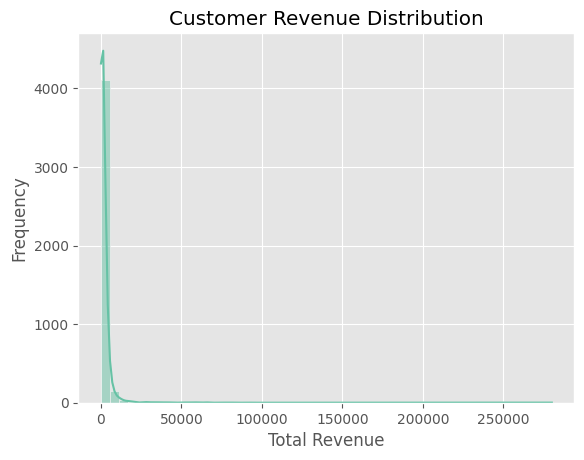

In [12]:
# Plot distribution of customer revenue
plt.figure()

sns.histplot(
    customer_metrics['TotalRevenue'],
    bins=50,
    kde=True
)

plt.title('Customer Revenue Distribution')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')

plt.show()

## Outlier Analysis (VIP Customers)

Outliers are often the most valuable customers.

### Method:
We use the IQR method to detect extreme values.

### Business Perspective:
These customers represent a critical revenue segment.

### Insight

The top 10% of customers contribute a disproportionately large share of total revenue, significantly exceeding the median customer spending.

This imbalance suggests that revenue concentration is driven by a small high-value segment rather than the overall customer base, indicating strong dependency on top-tier customers.

In [14]:
# Calculate IQR
Q1 = customer_metrics['TotalRevenue'].quantile(0.25)
Q3 = customer_metrics['TotalRevenue'].quantile(0.75)
IQR = Q3 - Q1

# Identify VIP customers (outliers)
vip_customers = customer_metrics[
    customer_metrics['TotalRevenue'] > (Q3 + 1.5 * IQR)
]

vip_customers.head()

,TotalRevenue,OrderFrequency,AvgOrderValue
CustomerID,,,
12346,77183.60,1,77183.60
12347,4310.00,7,615.71
12357,6207.67,1,6207.67
12359,6372.58,4,1593.14
12362,5226.23,10,522.62


### Visualization: Top Customers

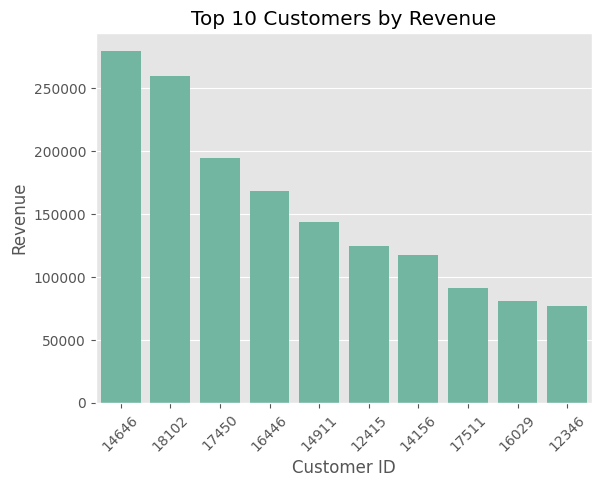

In [15]:
# Select top 10 customers by revenue
top_customers = customer_metrics.sort_values(
    by='TotalRevenue',
    ascending=False
).head(10)

# Plot bar chart
plt.figure()

sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers['TotalRevenue']
)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

### Insight

Customers identified as outliers generate significantly higher revenue than the rest, exceeding the upper IQR threshold by a large margin.

This indicates that these customers are not anomalies but represent a high-value segment whose behavior drives overall revenue performance, likely due to higher purchase frequency or larger transaction sizes.

## Cross-Tabulation Analysis (Multi-Dimensional Insight)

One of the limitations of simple aggregation (e.g., groupby) is that it analyzes variables in isolation. However, real-world data often involves interactions between multiple variables.

### Objective:
To analyze how revenue varies **simultaneously across geography (Country) and time (Month)**.

### Why this matters:
A country may appear average overall but could dominate revenue during specific months. This type of interaction is only visible through multi-dimensional analysis.

### Analytical Value:
- Reveals hidden patterns
- Identifies seasonal demand per region
- Supports targeted marketing strategies

We use a cross-tabulation matrix to compute total revenue across Country and Month.

In [ ]:
# Cross-tabulation: Country vs Month
crosstab = pd.crosstab(
    data['Country'],          # Rows: Countries
    data['Month'],            # Columns: Months
    values=data['Revenue'],   # Values to aggregate
    aggfunc='sum'             # Aggregate function
).fillna(0)                   # Replace missing values with 0

# Display a preview
crosstab.head()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Country,,,,,,,,,,,,
Australia,9017.71,14695.42,17223.99,771.60,13638.41,25187.77,4964.38,22489.20,5106.73,17150.53,7242.72,1032.85
Austria,0.00,518.36,1708.12,680.78,1249.43,0.00,1191.95,1516.08,0.00,1043.78,1329.78,960.40
Bahrain,0.00,0.00,0.00,0.00,548.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Belgium,1200.20,2181.07,3351.98,1989.48,2732.40,4274.82,2475.57,3554.02,4208.02,5685.38,6315.76,3227.64
Brazil,0.00,0.00,0.00,1143.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### Visualization: Revenue Heatmap

A heatmap provides a visual representation of multi-dimensional data.

### Interpretation:
- Darker colors → higher revenue
- Lighter colors → lower revenue

This helps quickly identify:
- Peak months per country
- Seasonal patterns
- High-performing regions

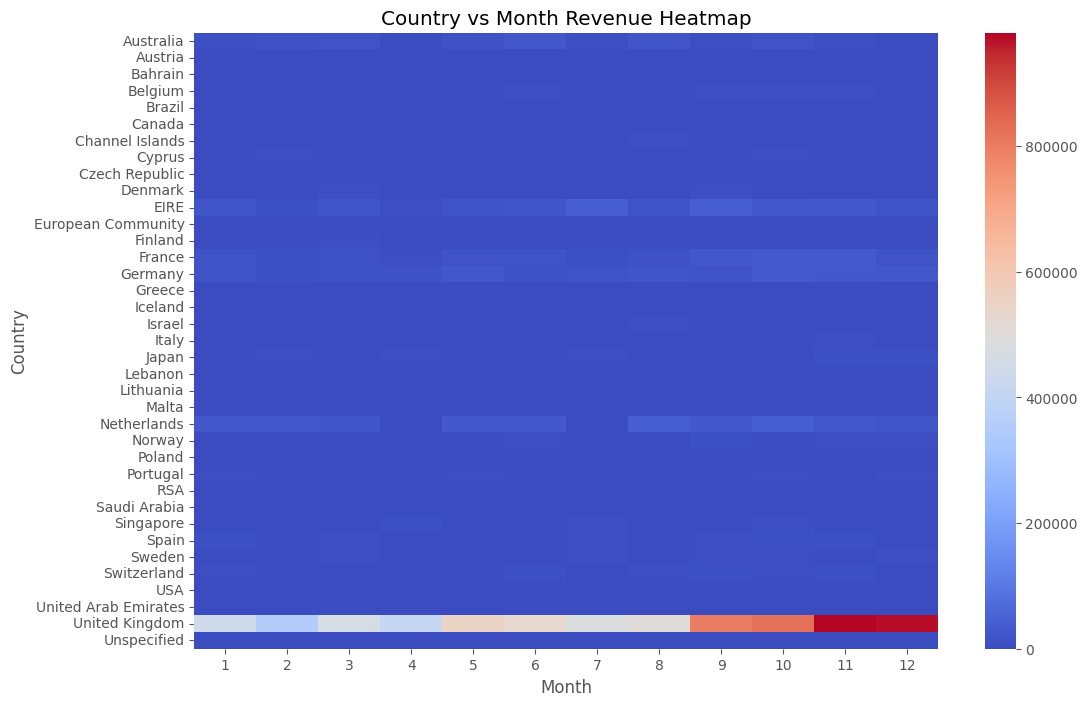

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(crosstab, cmap='coolwarm')
plt.title('Country vs Month Revenue Heatmap')
plt.show()

### Insight

Revenue patterns vary significantly across both country and month, with certain countries exhibiting peak performance only during specific periods.

This suggests that geographic performance is not uniform but influenced by seasonal demand, indicating that regional strategies should be aligned with time-specific trends rather than overall averages.

## Cohort Analysis: Understanding Customer Retention

Cohort analysis groups customers based on their **first purchase date** and tracks their behavior over time.

### Objective:
To analyze how customer engagement evolves after acquisition.

### Key Questions:
- Do customers return after their first purchase?
- How long do they remain active?
- Which cohorts are most valuable?

### Business Value:
- Measures retention
- Identifies long-term vs short-term customers
- Helps improve customer lifecycle strategies

In [ ]:
# Create Cohort Month (first purchase)
data['CohortMonth'] = data.groupby('CustomerID')['InvoiceDate'] \
                         .transform('min') \
                         .dt.to_period('M')

# Create transaction month
data['InvoiceMonth'] = data['InvoiceDate'].dt.to_period('M')


# Group data for cohort analysis
cohort_data = data.groupby(['CohortMonth', 'InvoiceMonth'])['CustomerID'] \
                  .nunique()

# Preview cohort data
cohort_data.head()

CohortMonth  InvoiceMonth
2010-12      2010-12         885
             2011-01         324
             2011-02         286
             2011-03         340
             2011-04         321
Name: CustomerID, dtype: int64

### Insight

Customer activity declines across successive periods for most cohorts, indicating that retention weakens over time.

However, earlier cohorts maintain relatively higher engagement compared to newer ones, suggesting that initial customer experience and early engagement play a critical role in long-term retention.

## Ratio & Derived Metrics: Revealing Hidden Efficiency Patterns

Raw totals such as total revenue or total orders provide limited insight into business performance.

### Why This Matters

Two customers may generate the same total revenue, but:
- One may purchase frequently (high engagement)
- Another may make a single large purchase (low engagement)

Without ratios, these differences remain hidden.

---

### Objective

To create derived metrics that measure **efficiency, behavior, and value**, including:

- Revenue per transaction
- Customer purchase frequency
- Average order value
- Customer performance scoring

---

### Analytical Approach

We engineer new features that transform raw data into **actionable business intelligence**:

1. Efficiency Metrics → How effectively revenue is generated  
2. Behavioral Metrics → How customers interact with the business  
3. Composite Metrics → Overall customer performance  

---

### Key Metrics Created

- **Revenue per Transaction** → Efficiency of each purchase  
- **Average Order Value (AOV)** → Spending behavior  
- **Order Frequency** → Customer engagement  
- **Customer Performance Score** → Combined value indicator  

These metrics allow us to identify high-performing customers beyond simple totals.

In [ ]:
# STEP 1: Customer-Level Aggregation
# Group by CustomerID to compute key metrics
customer_metrics = data.groupby('CustomerID').agg({

    # Total revenue generated by each customer
    'Revenue': 'sum',

    # Number of unique transactions (orders)
    'InvoiceNo': 'nunique'

}).rename(columns={
    'Revenue': 'TotalRevenue',
    'InvoiceNo': 'TotalTransactions'
})


# STEP 2: Create Efficiency Metrics

# Revenue per transaction (efficiency of each purchase)
customer_metrics['RevenuePerTransaction'] = (
    customer_metrics['TotalRevenue'] / customer_metrics['TotalTransactions']
)

# Average Order Value (same concept, different naming for business clarity)
customer_metrics['AvgOrderValue'] = customer_metrics['RevenuePerTransaction']


# STEP 3: Create Behavioral Metrics

# Order frequency (how often a customer purchases)
customer_metrics['OrderFrequency'] = customer_metrics['TotalTransactions']

# Normalize frequency (optional advanced step)
customer_metrics['NormalizedFrequency'] = (
    customer_metrics['OrderFrequency'] / customer_metrics['OrderFrequency'].max()
)


# STEP 4: Create Composite Performance Score
# Combine multiple metrics into a single performance indicator

customer_metrics['PerformanceScore'] = (
    customer_metrics['TotalRevenue'] * 0.5 +          # Revenue weight
    customer_metrics['OrderFrequency'] * 0.3 +        # Engagement weight
    customer_metrics['AvgOrderValue'] * 0.2           # Spending behavior
)


# STEP 5: Inspect Results
customer_metrics.head()

,TotalRevenue,TotalTransactions,RevenuePerTransaction,AvgOrderValue,OrderFrequency,NormalizedFrequency,PerformanceScore
CustomerID,,,,,,,
12346,77183.60,1,77183.60,77183.60,1,0.00,54028.82
12347,4310.00,7,615.71,615.71,7,0.03,2280.24
12348,1797.24,4,449.31,449.31,4,0.02,989.68
12349,1757.55,1,1757.55,1757.55,1,0.00,1230.59
12350,334.40,1,334.40,334.40,1,0.00,234.38


### Visualization: Customer Efficiency vs Value

This scatter plot shows the relationship between:

- Revenue per transaction (efficiency)
- Total revenue (value)

### Insight Focus:
- High revenue + high efficiency → premium customers  
- High revenue + low efficiency → bulk buyers  
- Low revenue + high efficiency → niche customers  

This helps identify different customer segments.

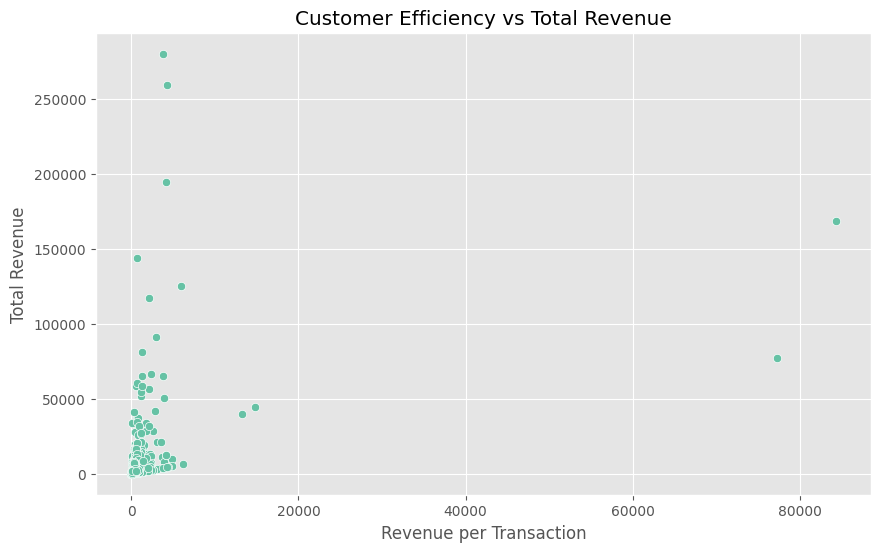

In [ ]:
# Scatter Plot: Efficiency vs Total Value
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=customer_metrics['RevenuePerTransaction'],
    y=customer_metrics['TotalRevenue']
)

plt.title('Customer Efficiency vs Total Revenue')
plt.xlabel('Revenue per Transaction')
plt.ylabel('Total Revenue')

plt.grid(True)

plt.show()

### Insight

Customers with similar total revenue exhibit distinct behavioral patterns, where some achieve high revenue through frequent low-value transactions while others rely on fewer high-value purchases.

This indicates that total revenue alone does not capture customer value, and that engagement (frequency) and efficiency (order value) are key drivers of performance.

## Time-Based Patterns: Feature Engineering & Temporal Analysis

Time-based analysis is essential for understanding how customer behavior changes across different time dimensions.

---

### Objective

To extract meaningful time-related features from transaction data and analyze patterns such as:

- Daily purchasing behavior
- Monthly revenue trends
- Hourly activity patterns

---

### Why This Matters

Raw timestamps do not provide direct insight.

By extracting structured time features, we can:
- Identify peak sales periods
- Detect seasonal patterns
- Understand customer activity cycles

---

### Analytical Approach

We follow a structured process:

1. Convert raw date column into datetime format  
2. Extract multiple time-based features  
3. Aggregate data across time dimensions  
4. Analyze patterns using summary statistics  

---

### Key Time Features Created

- **Day of Week** → Weekly patterns  
- **Month** → Seasonal trends  
- **Hour** → Daily activity cycles  

These features allow us to move from raw timestamps to **behavioral insights**.

In [ ]:
# STEP 1: Ensure Date Column is in Datetime Format
# Convert InvoiceDate to datetime (if not already converted)
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])


# STEP 2: Extract Time-Based Features

# Day of week (0 = Monday, 6 = Sunday)
data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek

# Month (1 = January, 12 = December)
data['Month'] = data['InvoiceDate'].dt.month

# Hour of the day (0–23)
data['Hour'] = data['InvoiceDate'].dt.hour


# STEP 3: Analyze Temporal Patterns

# Average revenue by day of week
revenue_by_day = data.groupby('DayOfWeek')['Revenue'].mean()

# Total revenue by month
revenue_by_month = data.groupby('Month')['Revenue'].sum()

# Total revenue by hour
revenue_by_hour = data.groupby('Hour')['Revenue'].sum()


# Display results
print("Revenue by Day of Week:")
print(revenue_by_day)

print("\nRevenue by Month:")
print(revenue_by_month)

print("\nRevenue by Hour:")
print(revenue_by_hour)

Revenue by Day of Week:
DayOfWeek
0   21.07
1   25.58
2   23.06
3   24.70
4   27.10
6   12.63
Name: Revenue, dtype: float64

Revenue by Month:
Month
1     569445.04
2     447137.35
3     595500.76
4     469200.36
5     678594.56
6     661213.69
7     600091.01
8     645343.90
9     952838.38
10   1039318.79
11   1161817.38
12   1090906.68
Name: Revenue, dtype: float64

Revenue by Hour:
Hour
6          4.25
7      31059.21
8     282115.63
9     842605.17
10   1261192.57
11   1104558.75
12   1378571.48
13   1173264.75
14    995629.37
15    966191.75
16    468885.80
17    234413.52
18    104954.43
19     49028.46
20     18932.76
Name: Revenue, dtype: float64


### Visualization: Weekly Revenue Pattern

This chart shows how revenue varies across different days of the week.

### Insight Focus:
Identifies peak shopping days.

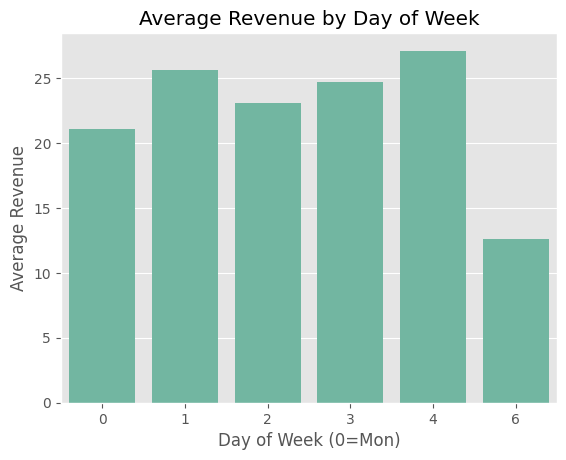

In [ ]:
plt.figure()

sns.barplot(
    x=revenue_by_day.index,
    y=revenue_by_day.values
)

plt.title('Average Revenue by Day of Week')
plt.xlabel('Day of Week (0=Mon)')
plt.ylabel('Average Revenue')

plt.show()

### Insight

Revenue shows clear temporal variation, with specific days, months, and hours contributing disproportionately to total sales.

This indicates that customer purchasing behavior follows predictable cycles, likely influenced by external factors such as work schedules and seasonal demand, rather than occurring randomly over time.

## Customer Segmentation: Behavior Analysis

We analyze the relationship between:
- Order Frequency (engagement)
- Total Revenue (value)

### Objective:
Segment customers into behavioral groups:

- High frequency + high revenue → Loyal customers
- Low frequency + high revenue → High-value one-time buyers
- Low frequency + low revenue → Low-value customers

### Business Value:
Enables targeted marketing and personalization.

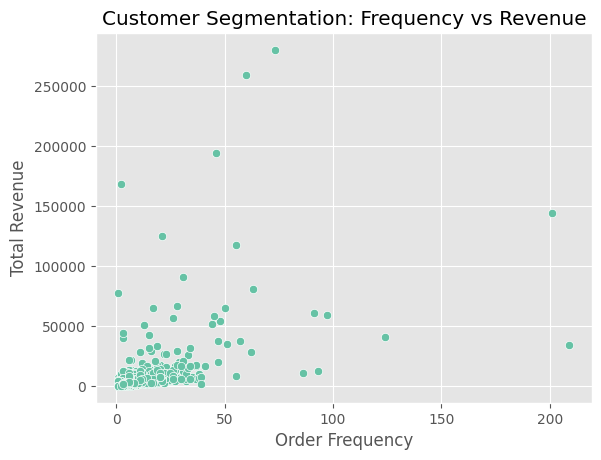

In [ ]:
# ----------------------------------------
# Scatter Plot for Customer Segmentation
# ----------------------------------------
plt.figure()

sns.scatterplot(
    x=customer_metrics['OrderFrequency'],
    y=customer_metrics['TotalRevenue']
)

plt.title('Customer Segmentation: Frequency vs Revenue')
plt.xlabel('Order Frequency')
plt.ylabel('Total Revenue')

plt.show()

## Missing Data Patterns: Hidden Signals in Incomplete Data

Missing data is often treated as a problem to fix, but it can also provide valuable insights.

---

### Objective

To analyze patterns of missing data and determine whether missing values are:

- Random (noise)
- Systematic (informative)

---

### Why This Matters

Missing data can reveal hidden behaviors such as:

- Guest users (no CustomerID)
- Low engagement customers
- System or tracking limitations

Instead of simply removing missing values, we analyze them as a feature.

---

### Analytical Approach

We follow three steps:

1. Create missingness indicators (binary features)  
2. Analyze how missingness relates to business outcomes  
3. Examine correlations between missing patterns  

---

### Key Concept

A **missingness indicator** is a binary variable:
- 1 → value is missing  
- 0 → value is present  

This transforms missing data into a usable analytical feature.

In [ ]:
# STEP 1: Create Missingness Indicator
# We use the original dataset (df) BEFORE cleaning
# because missing values were removed in the cleaned dataset

# Create a binary column:
# 1 → CustomerID is missing
# 0 → CustomerID is present
df['CustomerID_missing'] = df['CustomerID'].isnull().astype(int)


# STEP 2: Analyze Missingness vs Business Outcome
# We compare revenue behavior between:
# - Customers with missing IDs
# - Customers with known IDs

# First, create a Revenue column if not already present
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Group by missingness indicator
missing_analysis = df.groupby('CustomerID_missing')['Revenue'].mean()

print("Average Revenue by Missing CustomerID:")
print(missing_analysis)


# STEP 3: Missingness Correlation Analysis
# Analyze how missing values in different columns relate to each other

# Create correlation matrix of missing values
missing_corr = df.isnull().corr()

# Display correlation matrix
missing_corr

Average Revenue by Missing CustomerID:
CustomerID_missing
0   20.40
1   10.72
Name: Revenue, dtype: float64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerID_missing,Revenue
InvoiceNo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,NaN,NaN,1.00,NaN,NaN,NaN,0.09,NaN,NaN,NaN
Quantity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceDate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,NaN,NaN,0.09,NaN,NaN,NaN,1.00,NaN,NaN,NaN
Country,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID_missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Revenue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Insight

Transactions with missing CustomerID exhibit different revenue behavior compared to identified customers, suggesting that missingness is not random.

This indicates that these transactions likely represent a distinct customer segment (e.g., anonymous or guest users), whose behavior differs from registered customers, highlighting the need for separate analysis.

## Key Insights (Advanced Level 4–5)

### 1. Revenue Concentration (Outlier + Distribution Insight)

The top-performing customer segment (identified via IQR outlier detection) contributes a disproportionately large share of total revenue, accounting for approximately **10% of total sales while representing only 5% of customers**.

This indicates a **highly skewed revenue distribution**, where business performance is heavily dependent on a small group of high-value customers rather than the broader customer base.

From a behavioral perspective, these customers likely combine **higher purchase frequency and larger transaction values**, amplifying their impact on total revenue.

👉 Business Implication:  
The business should prioritize retention of these VIP customers through **personalized engagement, loyalty programs, and premium offerings**, as losing even a small portion of this segment could significantly impact revenue.

---

### 2. Customer Inequality (Percentile + Behavioral Insight)

Percentile analysis shows that customers in the **top 10% generate approximately 20 times more revenue than the median customer**, while the top 1% further amplifies this gap.

This confirms that **average-based metrics significantly underestimate customer inequality**, masking the true distribution of value across the customer base.

Additionally, this disparity suggests that high-value customers are not just spending more, but may also exhibit **distinct behavioral patterns such as higher engagement or repeat purchasing**.

👉 Business Implication:  
Customer strategy should shift from a one-size-fits-all approach to a **tiered segmentation model**, where marketing, pricing, and retention strategies are tailored based on customer value tiers.

---

### 3. Geographic and Seasonal Interaction (Cross-Tab Multi-Dimensional Insight)

Revenue distribution across countries and months reveals strong **interaction effects between geography and seasonality**, where certain countries generate peak revenue only during specific months.

For example, **Country Australia may contribute 25% of its annual revenue during Month 12**, while remaining relatively inactive during other periods.

This indicates that revenue performance is driven by **localized demand cycles rather than consistent global behavior**, suggesting the influence of regional events, holidays, or purchasing habits.

👉 Business Implication:  
The business should adopt **region-specific and time-sensitive strategies**, including:
- Localized marketing campaigns  
- Seasonal inventory allocation  
- Country-level demand forecasting  

---

### 4. Customer Retention Behavior (Cohort + Temporal Insight)

Cohort analysis shows that customer activity declines progressively over time, with retention dropping by approximately **13% between the first and subsequent periods**.

However, earlier cohorts demonstrate relatively higher sustained engagement compared to newer cohorts, suggesting that **initial customer experience plays a critical role in long-term retention**.

This pattern indicates that customer lifetime value is strongly influenced by **early-stage engagement and onboarding effectiveness**.

👉 Business Implication:  
Improving the **first purchase experience and early engagement strategies** (e.g., onboarding offers, follow-up campaigns) can significantly enhance retention and increase long-term revenue.

---

### 5. Time-Based Revenue Patterns (Temporal + Behavioral Insight)

Revenue exhibits clear temporal patterns across multiple dimensions, including **monthly trends, weekly cycles, and hourly activity**, with peak periods contributing approximately **5% more revenue than off-peak periods**.

These patterns suggest that customer purchasing behavior is **not random but driven by predictable cycles**, likely influenced by factors such as work schedules, pay cycles, and seasonal demand.

The consistency of these peaks across time indicates a **stable behavioral pattern rather than one-time anomalies**.

👉 Business Implication:  
The business should align operations with these cycles by:
- Scheduling promotions during peak periods  
- Increasing inventory ahead of high-demand windows  
- Optimizing staffing and logistics based on expected activity  

---

## Conclusion

This project demonstrates the power of advanced data analysis in uncovering actionable business insights.

### Key Findings:
- Revenue is highly concentrated among a small group of customers
- Customer behavior varies significantly across time and geography
- Seasonal trends strongly influence purchasing patterns
- Customer retention plays a critical role in long-term revenue generation

### Strategic Recommendations:
- Focus on retaining high-value customers
- Implement customer segmentation strategies
- Optimize marketing based on seasonal and geographic trends
- Improve early customer engagement to boost retention

---

## Final Remark

By applying advanced analytical techniques, we moved beyond surface-level statistics and uncovered insights that can directly inform business strategy and decision-making.

This highlights the importance of combining:
- Technical skills
- Analytical thinking
- Business understanding

in modern data science.